# **1. Perkenalan Dataset**


## Dataset: German Credit Risk

Dataset ini diperoleh dari **Kaggle** ([German Credit Risk](https://www.kaggle.com/datasets/uciml/german-credit)) yang merupakan dataset klasifikasi untuk memprediksi risiko kredit pelanggan.

### Informasi Dataset:
- **Jumlah data**: 1000 baris, 10 kolom
- **Target**: `Risk` — nilai 1 (good credit) dan 0 (bad credit)
- **Fitur**: Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount, Duration, Purpose
- **Tipe masalah**: Binary Classification

### Tujuan:
Membangun model machine learning untuk mengklasifikasikan apakah seorang pemohon kredit termasuk risiko tinggi atau rendah berdasarkan atribut demografis dan keuangan mereka.

# **2. Import Library**

Mengimpor library Python yang dibutuhkan untuk analisis data, visualisasi, dan preprocessing.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.6


# **3. Memuat Dataset**

Memuat dataset German Credit Risk dari file CSV dan memeriksa beberapa baris awal untuk memahami struktur data.

In [15]:
# Load dataset
df = pd.read_csv('../credit_scoring_raw.csv', index_col=0)

# Tampilkan 5 baris pertama
print('=== 5 Baris Pertama Dataset ===')
print(df.head())

=== 5 Baris Pertama Dataset ===
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  


In [16]:
print('=== Informasi Dataset ===')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
print('=== Tipe Data ===')
print(df.dtypes)

=== Informasi Dataset ===
Shape: (1000, 10)
Jumlah baris: 1000
Jumlah kolom: 10

=== Tipe Data ===
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


In [17]:
print('=== Statistik Deskriptif ===')
df.describe(include='all')

=== Statistik Deskriptif ===


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi data untuk memahami karakteristik dataset, distribusi data, dan hubungan antar fitur.

In [18]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal kolom dengan missing values: {(missing > 0).sum()}')

=== Missing Values ===
                  Missing Count  Missing %
Saving accounts             183       18.3
Checking account            394       39.4

Total kolom dengan missing values: 2


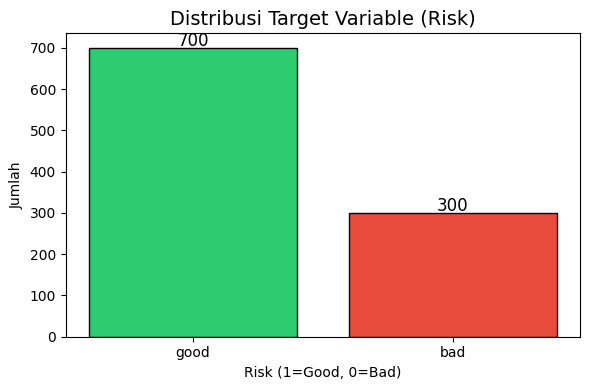


Distribusi Risk:
Risk
good    700
bad     300
Name: count, dtype: int64

Persentase:
Risk
good    70.0
bad     30.0
Name: count, dtype: float64


In [19]:
# 4.2 Distribusi Target Variable
plt.figure(figsize=(6, 4))
risk_counts = df['Risk'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black')
plt.title('Distribusi Target Variable (Risk)', fontsize=14)
plt.xlabel('Risk (1=Good, 0=Bad)')
plt.ylabel('Jumlah')
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.show()
print(f'\nDistribusi Risk:')
print(risk_counts)
print(f'\nPersentase:')
print((risk_counts / len(df) * 100).round(2))

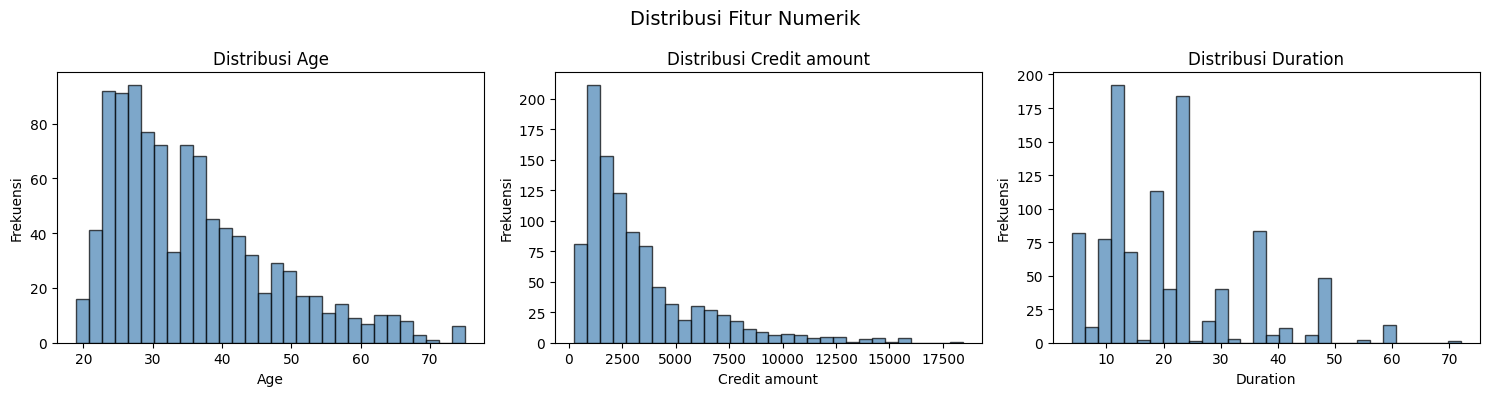

In [20]:
# 4.3 Distribusi Fitur Numerik
num_cols = ['Age', 'Credit amount', 'Duration']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

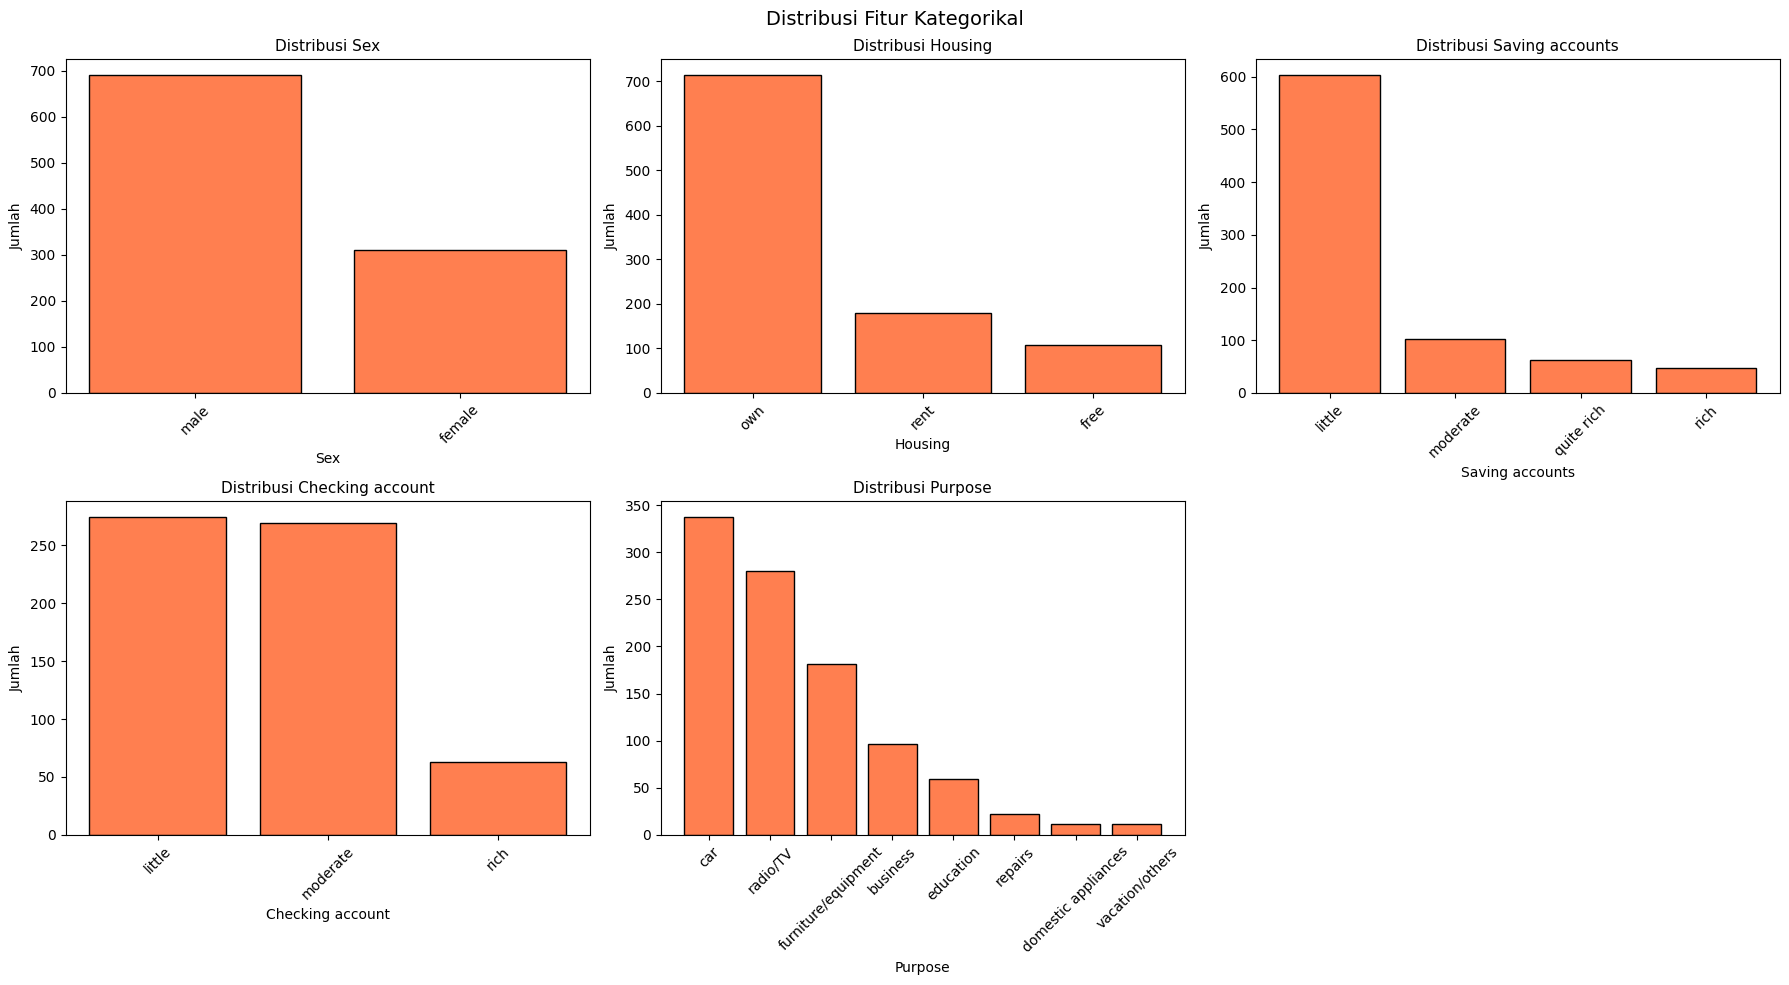

In [21]:
# 4.4 Distribusi Fitur Kategorikal
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='coral', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)

# Sembunyikan subplot kosong
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14)
plt.tight_layout()
plt.show()

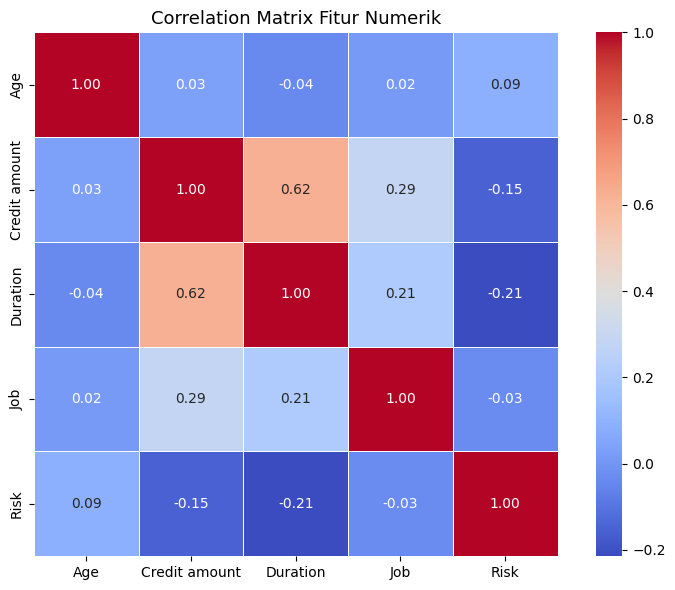

In [22]:
# 4.5 Korelasi antar fitur numerik
num_df = df[num_cols + ['Job', 'Risk']].copy()

# Encode kolom kategorikal yang ingin diikutkan
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
num_df['Risk'] = le.fit_transform(num_df['Risk'])  # 'bad'=0, 'good'=1

plt.figure(figsize=(8, 6))
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

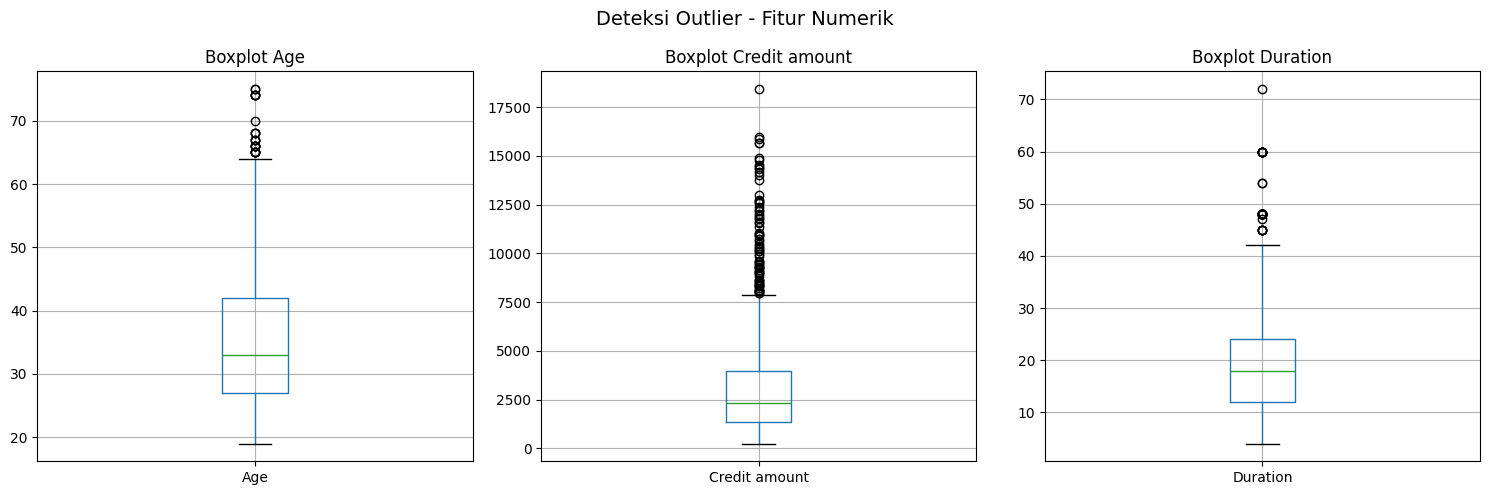

In [23]:
# 4.6 Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot {col}', fontsize=12)

plt.suptitle('Deteksi Outlier - Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

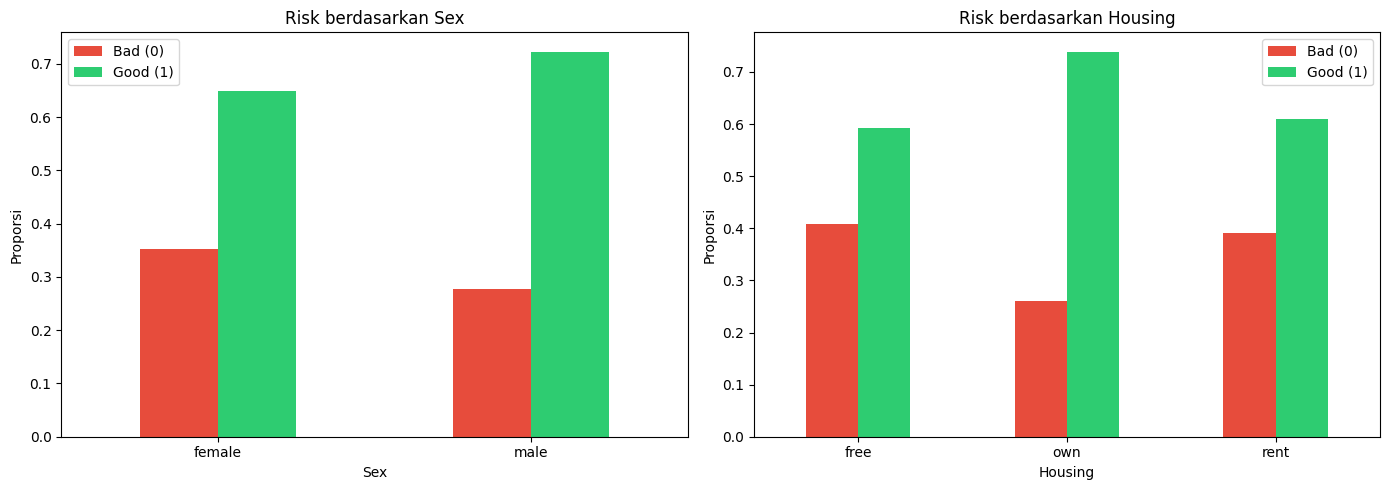

In [24]:
# 4.7 Analisis Risk berdasarkan fitur kategorikal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk by Sex
risk_sex = df.groupby('Sex')['Risk'].value_counts(normalize=True).unstack()
risk_sex.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Risk berdasarkan Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Proporsi')
axes[0].legend(['Bad (0)', 'Good (1)'])
axes[0].tick_params(axis='x', rotation=0)

# Risk by Housing
risk_housing = df.groupby('Housing')['Risk'].value_counts(normalize=True).unstack()
risk_housing.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Risk berdasarkan Housing')
axes[1].set_xlabel('Housing')
axes[1].set_ylabel('Proporsi')
axes[1].legend(['Bad (0)', 'Good (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [25]:
# 4.8 Cek duplikat
print('=== Pengecekan Data Duplikat ===')
dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')
print(f'Persentase: {(dup_count/len(df)*100):.2f}%')

=== Pengecekan Data Duplikat ===
Jumlah baris duplikat: 0
Persentase: 0.00%


# **5. Data Preprocessing**

Melakukan preprocessing data untuk mempersiapkan dataset agar siap digunakan dalam pelatihan model machine learning.

Tahapan preprocessing yang dilakukan:
1. Menangani Missing Values
2. Menghapus Data Duplikat
3. Encoding Data Kategorikal
4. Deteksi dan Penanganan Outlier (IQR Method)
5. Normalisasi Fitur Numerik
6. Split Dataset (Train/Test)

In [26]:
# Buat salinan dataset untuk preprocessing
df_processed = df.copy()
print(f'Shape awal: {df_processed.shape}')

Shape awal: (1000, 10)


In [27]:
# 5.1 Menangani Missing Values
print('=== Sebelum Menangani Missing Values ===')
print(df_processed.isnull().sum())

# Isi missing values kategorikal dengan modus
cat_cols_fill = ['Saving accounts', 'Checking account']
for col in cat_cols_fill:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f'Kolom "{col}": missing values diisi dengan modus = "{mode_val}"')

print('\n=== Setelah Menangani Missing Values ===')
print(df_processed.isnull().sum())

=== Sebelum Menangani Missing Values ===
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64
Kolom "Saving accounts": missing values diisi dengan modus = "little"
Kolom "Checking account": missing values diisi dengan modus = "little"

=== Setelah Menangani Missing Values ===
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [28]:
# 5.2 Menghapus Data Duplikat
print(f'Shape sebelum hapus duplikat: {df_processed.shape}')
df_processed.drop_duplicates(inplace=True)
df_processed.reset_index(drop=True, inplace=True)
print(f'Shape setelah hapus duplikat: {df_processed.shape}')

Shape sebelum hapus duplikat: (1000, 10)
Shape setelah hapus duplikat: (1000, 10)


In [29]:
# 5.3 Encoding Data Kategorikal (Label Encoding)
print('=== Encoding Data Kategorikal ===')
cat_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
encoders = {}

for col in cat_features:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    encoders[col] = le
    print(f'Kolom "{col}" — Classes: {list(le.classes_)}')

print('\nData setelah encoding:')
print(df_processed.head())

=== Encoding Data Kategorikal ===
Kolom "Sex" — Classes: ['female', 'male']
Kolom "Housing" — Classes: ['free', 'own', 'rent']
Kolom "Saving accounts" — Classes: ['little', 'moderate', 'quite rich', 'rich']
Kolom "Checking account" — Classes: ['little', 'moderate', 'rich']
Kolom "Purpose" — Classes: ['business', 'car', 'domestic appliances', 'education', 'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others']

Data setelah encoding:
   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                0                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 0           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   Duration  Purpose  Risk  
0         6        5  good  
1        48        5 

In [30]:
# 5.4 Deteksi dan Penanganan Outlier dengan IQR
print('=== Penanganan Outlier (IQR Method) ===')
num_features = ['Age', 'Credit amount', 'Duration']

outlier_info = {}
for col in num_features:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    outlier_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower': lower, 'Upper': upper, 'Outliers': outliers}
    
    # Clip outlier (winsorization)
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)
    print(f'{col}: {outliers} outlier di-clip ke [{lower:.2f}, {upper:.2f}]')

print(f'\nShape setelah penanganan outlier: {df_processed.shape}')

=== Penanganan Outlier (IQR Method) ===
Age: 23 outlier di-clip ke [4.50, 64.50]
Credit amount: 72 outlier di-clip ke [-2544.62, 7882.38]
Duration: 70 outlier di-clip ke [-6.00, 42.00]

Shape setelah penanganan outlier: (1000, 10)


In [31]:
# 5.5 Normalisasi / Standarisasi Fitur Numerik
print('=== Standarisasi Fitur Numerik (StandardScaler) ===')
scaler = StandardScaler()

# Pisahkan fitur dan target sebelum scaling
X = df_processed.drop(columns=['Risk'])
y = df_processed['Risk']

X[num_features] = scaler.fit_transform(X[num_features])

print('Sebelum scaling (mean, std):')
for col in num_features:
    print(f'  {col}: mean={X[col].mean():.4f}, std={X[col].std():.4f}')

=== Standarisasi Fitur Numerik (StandardScaler) ===
Sebelum scaling (mean, std):
  Age: mean=0.0000, std=1.0005
  Credit amount: mean=-0.0000, std=1.0005
  Duration: mean=0.0000, std=1.0005


In [32]:
# 5.6 Split Dataset Train / Test
print('=== Split Dataset ===')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data  : {len(X)}')
print(f'Train data  : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test data   : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nDistribusi target train:')
print(y_train.value_counts())
print(f'\nDistribusi target test:')
print(y_test.value_counts())

=== Split Dataset ===
Total data  : 1000
Train data  : 800 (80.0%)
Test data   : 200 (20.0%)

Distribusi target train:
Risk
good    560
bad     240
Name: count, dtype: int64

Distribusi target test:
Risk
good    140
bad      60
Name: count, dtype: int64


In [33]:
# 5.7 Simpan hasil preprocessing
import os
os.makedirs('credit_scoring_preprocessing', exist_ok=True)

# Gabungkan X dan y untuk disimpan
train_df = X_train.copy()
train_df['Risk'] = y_train.values

test_df = X_test.copy()
test_df['Risk'] = y_test.values

train_df.to_csv('credit_scoring_preprocessing/train.csv', index=False)
test_df.to_csv('credit_scoring_preprocessing/test.csv', index=False)

print('=== Dataset Preprocessing Berhasil Disimpan ===')
print(f'Train saved : credit_scoring_preprocessing/train.csv ({len(train_df)} rows)')
print(f'Test saved  : credit_scoring_preprocessing/test.csv ({len(test_df)} rows)')
print(f'\nKolom dataset:')
print(list(train_df.columns))

=== Dataset Preprocessing Berhasil Disimpan ===
Train saved : credit_scoring_preprocessing/train.csv (800 rows)
Test saved  : credit_scoring_preprocessing/test.csv (200 rows)

Kolom dataset:
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


## Ringkasan Preprocessing

| Tahapan | Detail |
|---|---|
| Missing Values | Diisi dengan modus untuk kolom 'Saving accounts' dan 'Checking account' |
| Duplikat | Dihapus (jika ada) |
| Encoding | Label Encoding untuk 5 fitur kategorikal |
| Outlier | Ditangani dengan metode IQR clipping (winsorization) |
| Normalisasi | StandardScaler pada fitur numerik (Age, Credit amount, Duration) |
| Split | 80% train, 20% test dengan stratified sampling |